In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
#Load dataset
df = pd.read_csv('heart_disease.csv')

In [3]:
print("Initial shape:", df.shape)

Initial shape: (10000, 21)


In [4]:
#Identify missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age                     29
Gender                  19
Blood Pressure          19
Cholesterol Level       30
Exercise Habits         25
Smoking                 25
Family Heart Disease    21
Diabetes                30
BMI                     22
High Blood Pressure     26
Low HDL Cholesterol     25
High LDL Cholesterol    26
Alcohol Consumption     32
Stress Level            22
Sleep Hours             25
Sugar Consumption       30
Triglyceride Level      26
Fasting Blood Sugar     22
CRP Level               26
Homocysteine Level      20
Heart Disease Status     0
dtype: int64


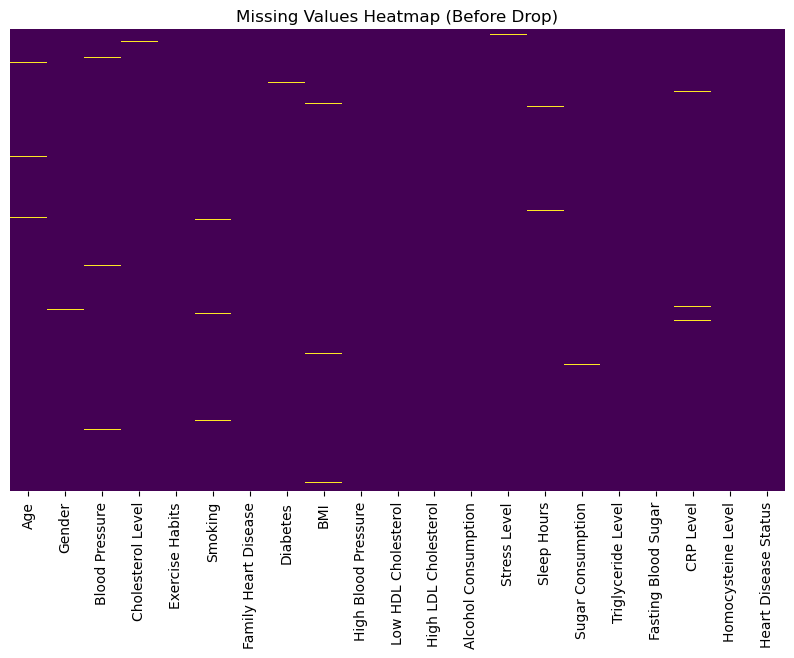

In [5]:
#Visualization of missing data before dropping
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap (Before Drop)")
plt.show()

In [6]:
#Dropping missing values
df.dropna(inplace=True)
print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (9500, 21)


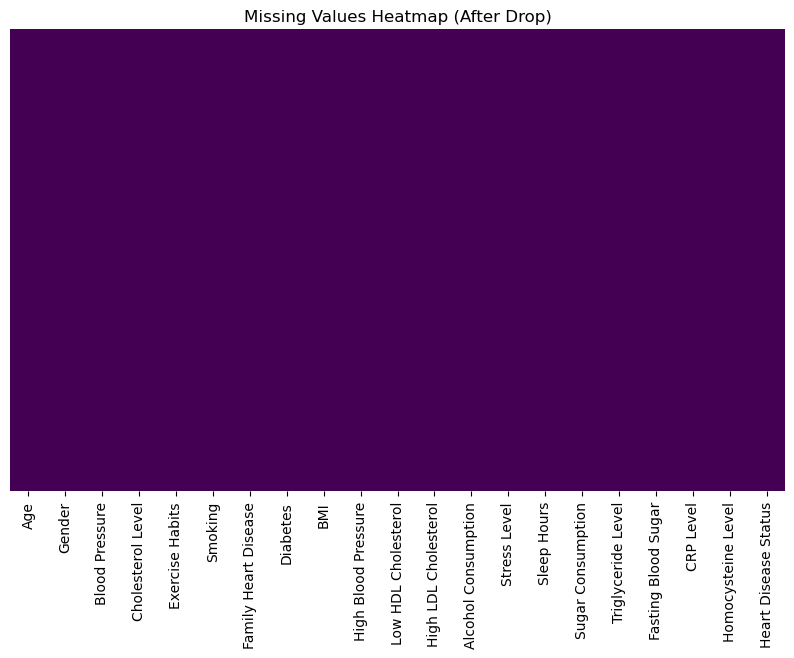

In [7]:
#Visualization of missing data after dropping
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap (After Drop)")
plt.show()

In [8]:
#Identifying categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

Categorical columns to encode: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']


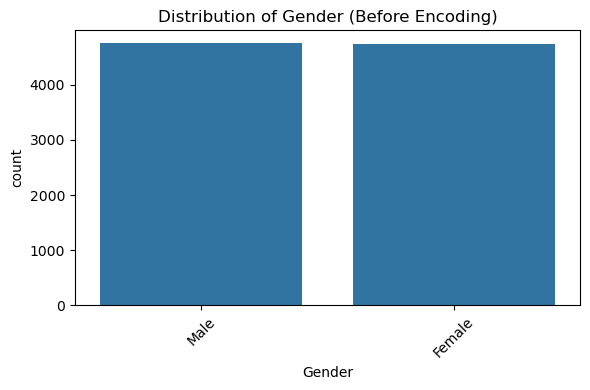

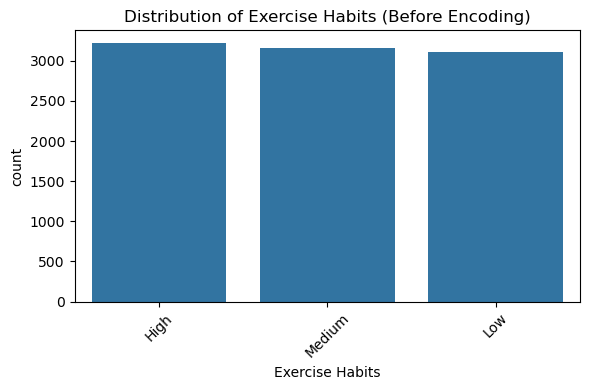

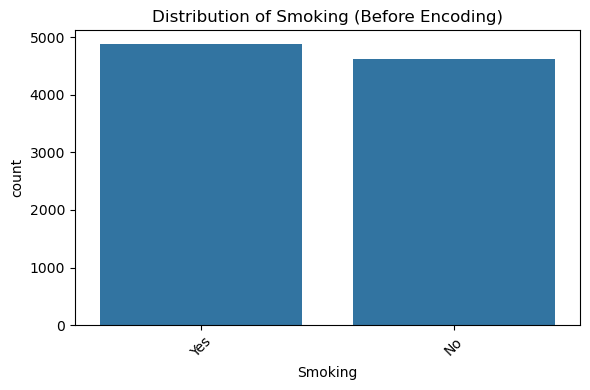

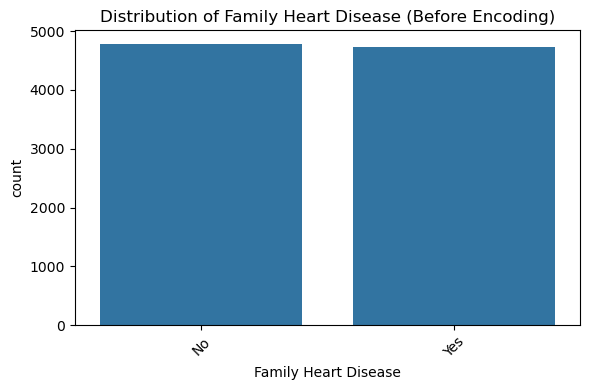

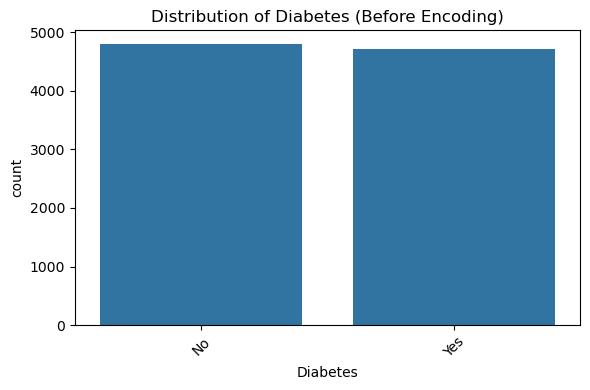

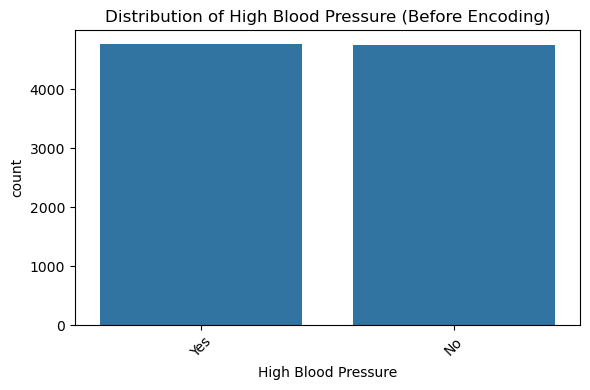

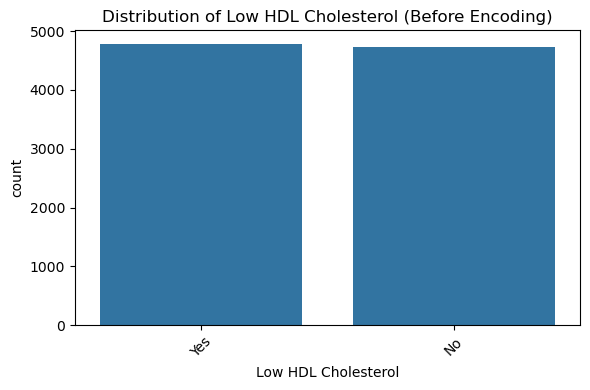

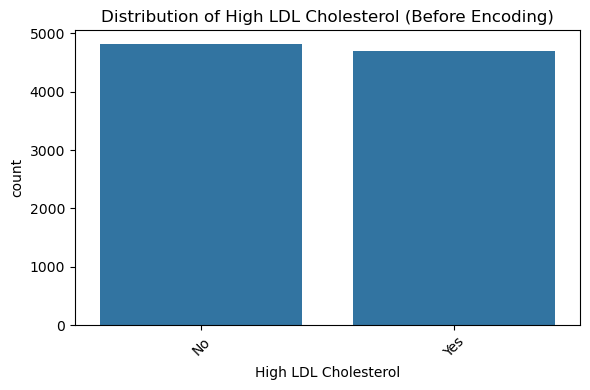

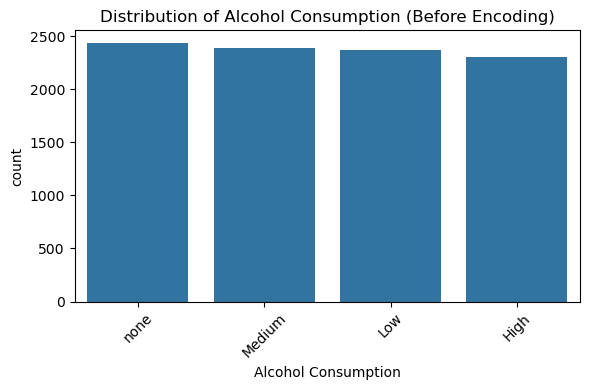

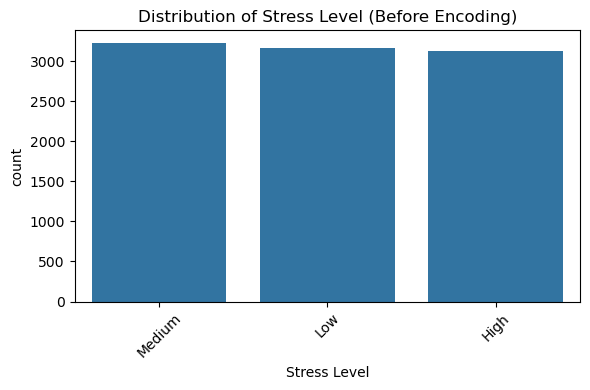

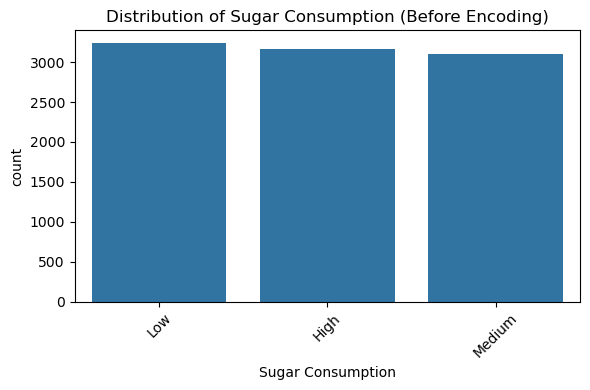

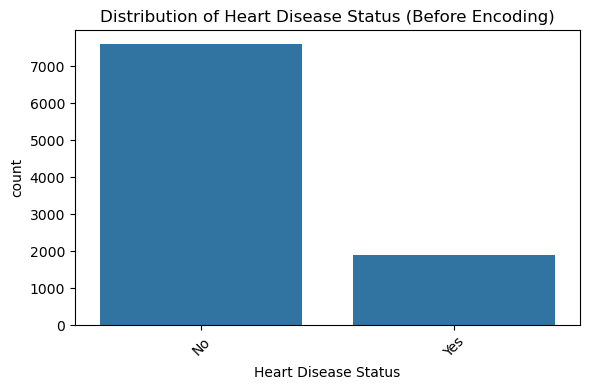

In [9]:
#Visualization of categorical columns before encoding
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} (Before Encoding)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
#Applying label encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
#Confirm all are numerical after encoding
print("Data types after encoding:")
print(df.dtypes)

Data types after encoding:
Age                     float64
Gender                    int64
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits           int64
Smoking                   int64
Family Heart Disease      int64
Diabetes                  int64
BMI                     float64
High Blood Pressure       int64
Low HDL Cholesterol       int64
High LDL Cholesterol      int64
Alcohol Consumption       int64
Stress Level              int64
Sleep Hours             float64
Sugar Consumption         int64
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status      int64
dtype: object


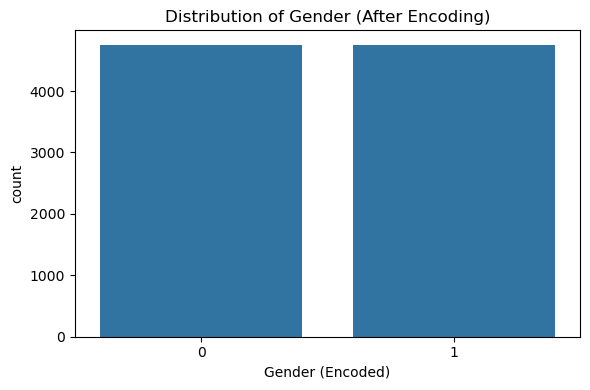

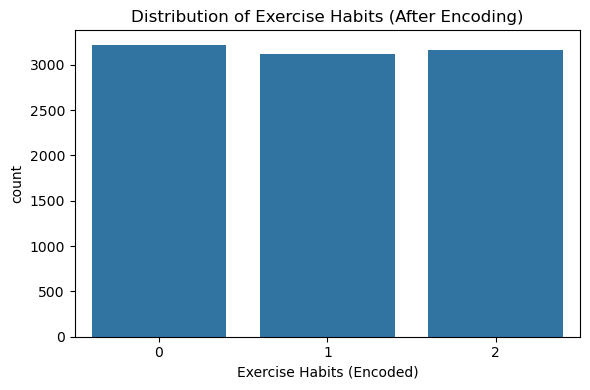

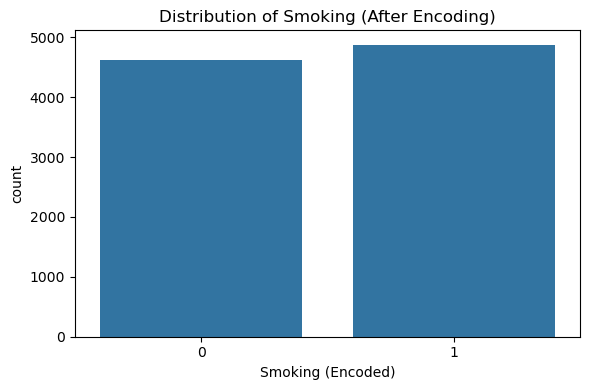

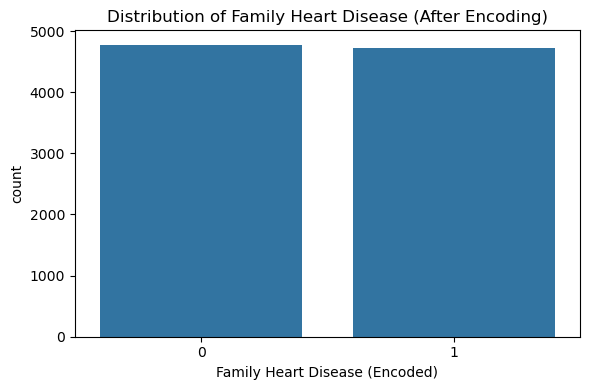

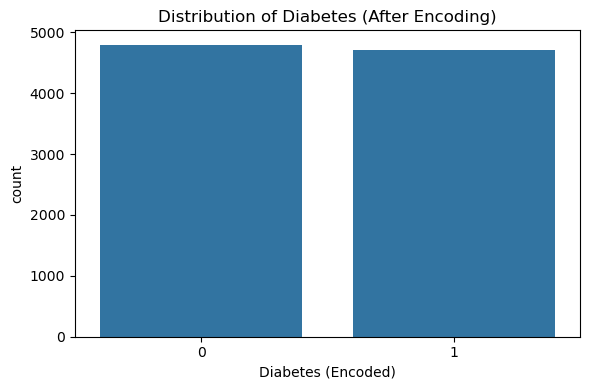

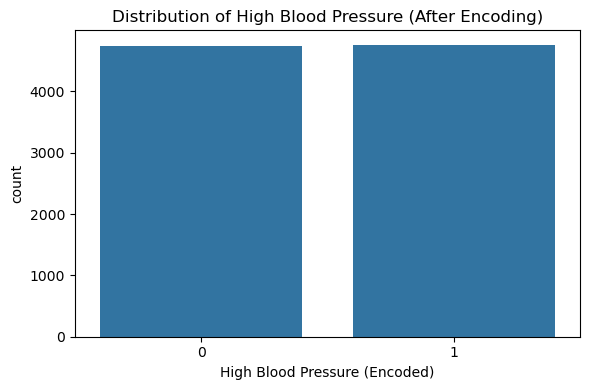

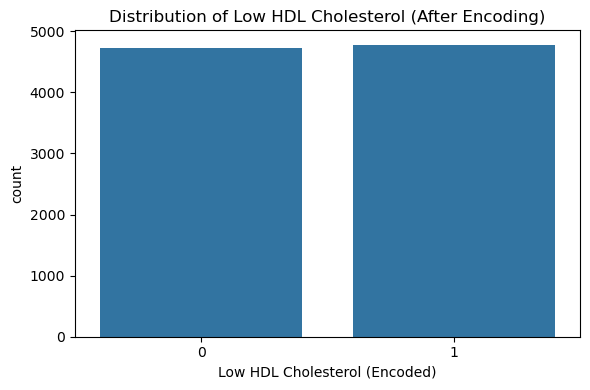

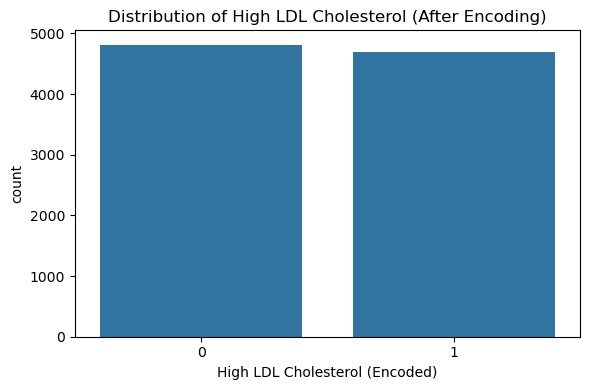

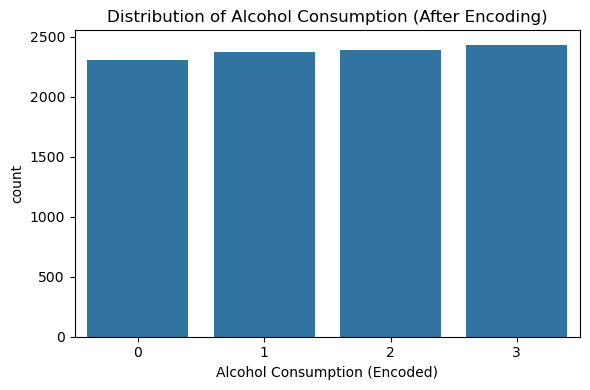

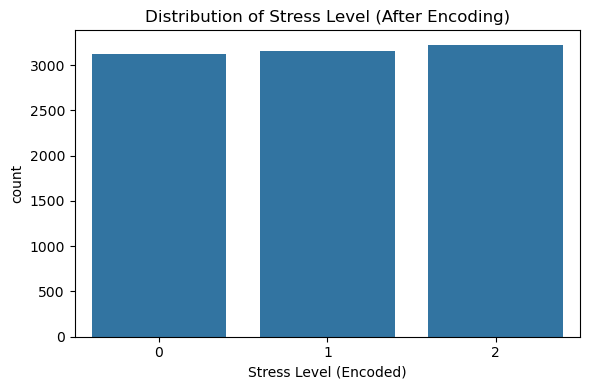

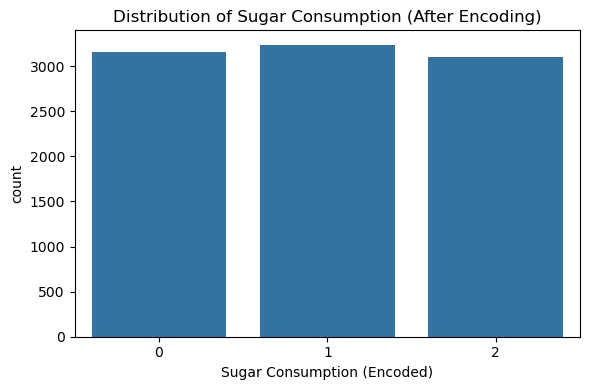

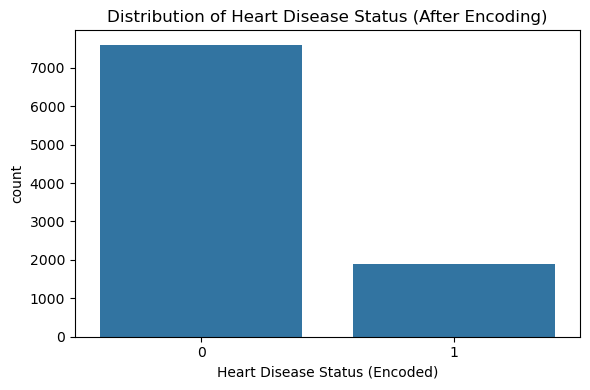

In [12]:
#Visualization after encoding
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col} (After Encoding)')
    plt.xlabel(f'{col} (Encoded)')
    plt.tight_layout()
    plt.show()